In [110]:
#Importar bibliotecas
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [111]:
df = pd.read_csv("aprobacion.csv")
df

,ingresos,aprobacion
0,2.48,1
1,6.90,0
2,3.90,0
3,2.18,0
4,6.04,1
...,...,...
95,4.75,0
96,4.89,1
97,2.41,0
98,4.32,0


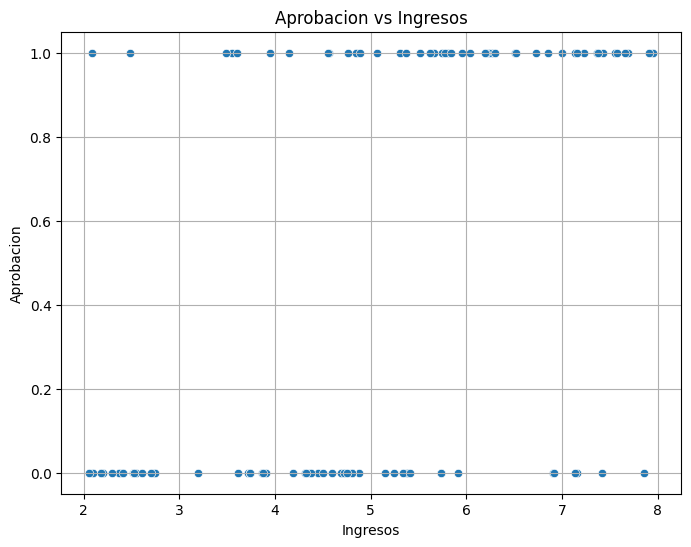

In [112]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='ingresos', y='aprobacion', data=df)
plt.title('Aprobacion vs Ingresos')
plt.xlabel('Ingresos')
plt.ylabel('Aprobacion')
plt.grid(True)
plt.show()

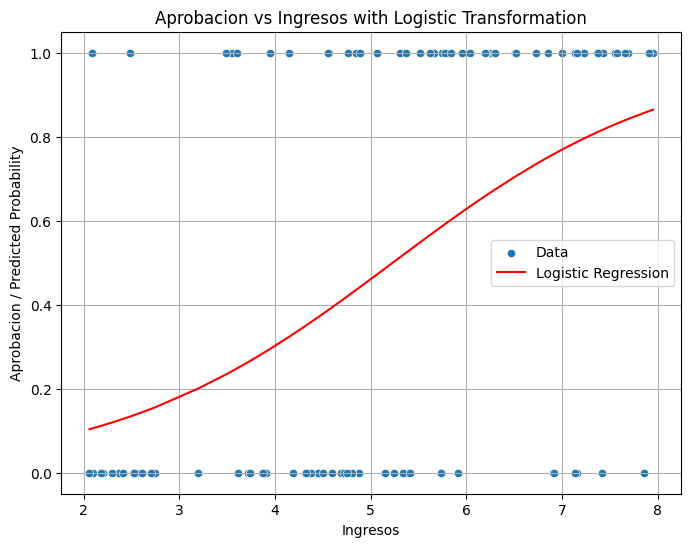

In [113]:
from sklearn.linear_model import LogisticRegression

# Prepare data for logistic regression
X = df[['ingresos']]
y = df['aprobacion']

# Fit logistic regression model
model = LogisticRegression()
model.fit(X, y)

# Predict probabilities
df['predicted_prob'] = model.predict_proba(X)[:, 1]

# Plot the data and the logistic curve
plt.figure(figsize=(8, 6))
sns.scatterplot(x='ingresos', y='aprobacion', data=df, label='Data')
sns.lineplot(x='ingresos', y='predicted_prob', data=df.sort_values('ingresos'), color='red', label='Logistic Regression')

plt.title('Aprobacion vs Ingresos with Logistic Transformation')
plt.xlabel('Ingresos')
plt.ylabel('Aprobacion / Predicted Probability')
plt.grid(True)
plt.legend()
plt.show()

In [114]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

model= smf.logit('aprobacion ~ ingresos', data=df).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.557863
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:             aprobacion   No. Observations:                  100
Model:                          Logit   Df Residuals:                       98
Method:                           MLE   Df Model:                            1
Date:                Sat, 06 Sep 2025   Pseudo R-squ.:                  0.1931
Time:                        03:32:07   Log-Likelihood:                -55.786
converged:                       True   LL-Null:                       -69.135
Covariance Type:            nonrobust   LLR p-value:                 2.380e-07
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -3.6434      0.833     -4.373      0.000      -5.276      -2.010
ingresos       0.6971      0.

- *intercept es la b (-3.6434)*
- *ingresos es la m(0.6971)*

*Prueba estadística*
* H0: La variable es igual a cero
* H1: La variable no es cero

*P>|z| = P valor*

* La b si debe ir en el modelo
* ingresos también debe estar en el modelo


*Nuestra prueba*
- X = 1.2  (120,000)
- MODELO  P = 1 / (1 + e ^-(0.7X -3.6))
- Respuesta = 0.059 = 5.9% de probabilidad de que le den su crédito :(

- X = 5.2 mínimo para que le den el crédito (P >50%)

In [115]:
#MODELO
import numpy as np
x = 5.2
p = 1/(1+np.exp(-(0.7*x-3.6)))
print(p)

0.5099986668799654


**5.2 SERÁ NUESTRO PUNTO DE CORTE**

In [116]:
#POV: APRENDIZAJE MÁQUINA
#sklearn -> biblioteca de ciencia de datos

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [117]:
x=df.drop(['aprobacion'], axis=1)
y=df.aprobacion

In [118]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [119]:
modelo = LogisticRegression()   #Utilizo modelo de Regresión Logistica
modelo.fit(X_train, y_train)  #Con que lo voy a ajustar

LogisticRegression()

In [120]:
print("Coeficientes del modelo:", modelo.coef_)
print("Intercepto del modelo:", modelo.intercept_)

Coeficientes del modelo: [[0.64373227 0.13633223]]
Intercepto del modelo: [-3.57872953]


In [150]:
# Predict probability for a new instance with ingresos = 1.2
tp = pd.DataFrame([1.2]).T  #T de transpuesta
tp.columns = ['ingresos']

# Use the sklearn model trained on aprobacion.csv
p = model_aprobacion_sklearn.predict_proba(tp)[:, 1]

p

NameError: name 'model_aprobacion_sklearn' is not defined

In [124]:
#USANDO LA PRUEBA (20)  PREDICCIONES DE LAS Y QUE DEJE COMO PRUEBA
y_pred = modelo.predict(X_test)
cnf = confusion_matrix(y_test, y_pred)  #comparar
#y_test los verdaderos valores
#y_pred los que el modelo predice si les darán o no crédito
print(cnf)

[[10  0]
 [ 3  7]]


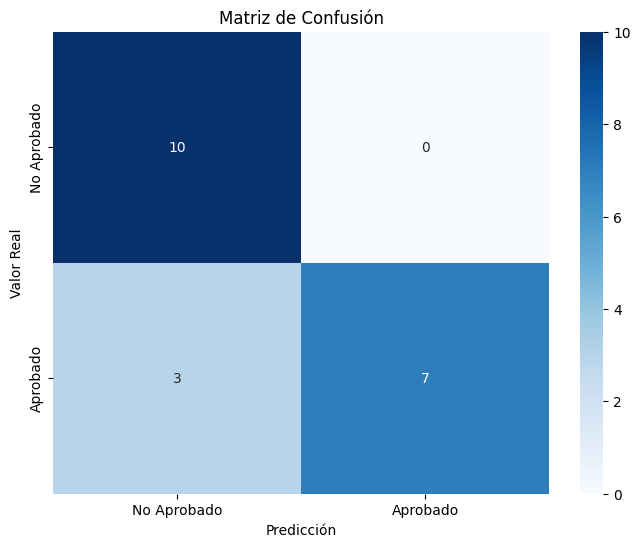

In [125]:
#CONTRUYE LA MATRIZ DE CONFUSION

plt.figure(figsize=(8, 6))
sns.heatmap(cnf, annot=True, fmt='d', cmap='Blues', xticklabels=['No Aprobado', 'Aprobado'], yticklabels=['No Aprobado', 'Aprobado'])
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()

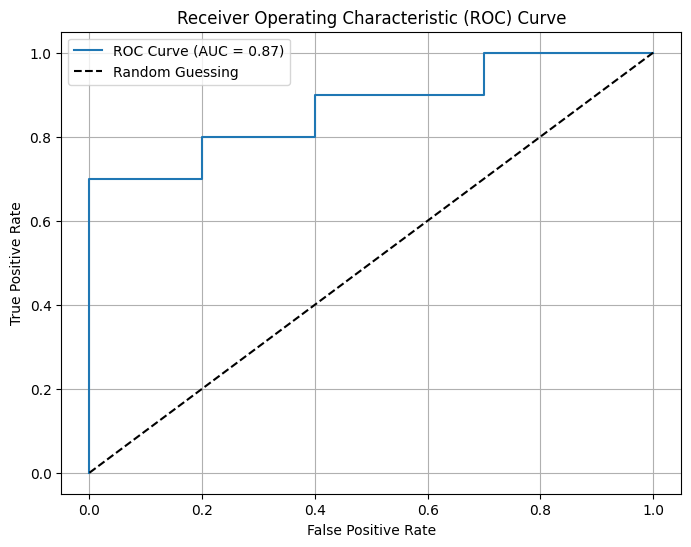

Area Under the ROC Curve (AUC): 0.87


In [126]:
#GRAFICA LA CURVA ROC
from sklearn.metrics import roc_curve, roc_auc_score

# Get predicted probabilities for the test set
y_pred_proba = modelo.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Calculate AUC
auc = roc_auc_score(y_test, y_pred_proba)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing') # Random guessing line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid(True)
plt.show()

print(f"Area Under the ROC Curve (AUC): {auc:.2f}")

**NUESTRO MODELO LE ATINA EL 86% DE LAS VECES**

In [127]:
df = pd.read_csv("accident.csv")
df

,age,gender,speed,helmet,seatbelt,survived
0,18,Female,20,No,Yes,1
1,28,Male,20,Yes,No,1
2,52,Male,20,Yes,No,1
3,52,Female,20,No,No,1
4,37,Female,21,No,No,1
...,...,...,...,...,...,...
195,50,Female,118,Yes,Yes,0
196,59,Female,118,Yes,No,0
197,67,Female,118,Yes,No,0
198,24,Female,119,Yes,Yes,0


In [129]:
# Select features and target variable
X = df[['age', 'gender', 'speed', 'helmet', 'seatbelt']]
y = df['survived']

**Reasoning**:
Split the feature and target data into training and testing sets as instructed.



In [130]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (160, 5)
X_test shape: (40, 5)
y_train shape: (160,)
y_test shape: (40,)


## Train model

### Subtask:
Train a logistic regression model on the training data.


**Reasoning**:
Instantiate and fit the LogisticRegression model to the training data.



In [148]:
# Instantiate a LogisticRegression model
model = LogisticRegression()

# Fit the model to the training data
model.fit(X_train, y_train)

LogisticRegression()

In [132]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Identify categorical and numerical features
categorical_features = ['gender', 'helmet', 'seatbelt']
numerical_features = ['age', 'speed']

# Create a column transformer for one-hot encoding
preprocessor = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough' # Keep numerical features
)

# Apply the transformer to the training and testing data
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

# Instantiate and fit the LogisticRegression model to the encoded training data
model = LogisticRegression()
model.fit(X_train_encoded, y_train)

LogisticRegression()

In [134]:
# Predict on the test set
y_pred = model.predict(X_test_encoded)

# Generate confusion matrix
cnf = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cnf)

# Calculate predicted probabilities for the positive class
y_pred_proba = model.predict_proba(X_test_encoded)[:, 1]

# Compute ROC curve metrics
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Calculate AUC
auc = roc_auc_score(y_test, y_pred_proba)
print(f"Area Under the ROC Curve (AUC): {auc:.2f}")

Confusion Matrix:
 [[17  3]
 [10 10]]
Area Under the ROC Curve (AUC): 0.79


**Reasoning**:
Plot the confusion matrix as a heatmap and the ROC curve with the AUC score to visualize the model's performance.



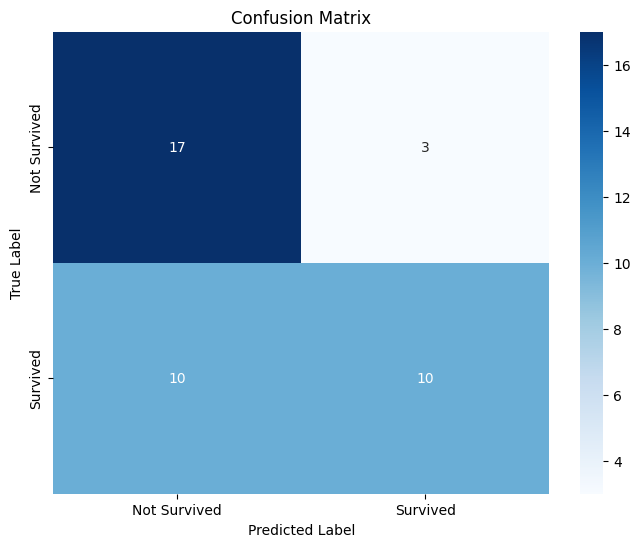

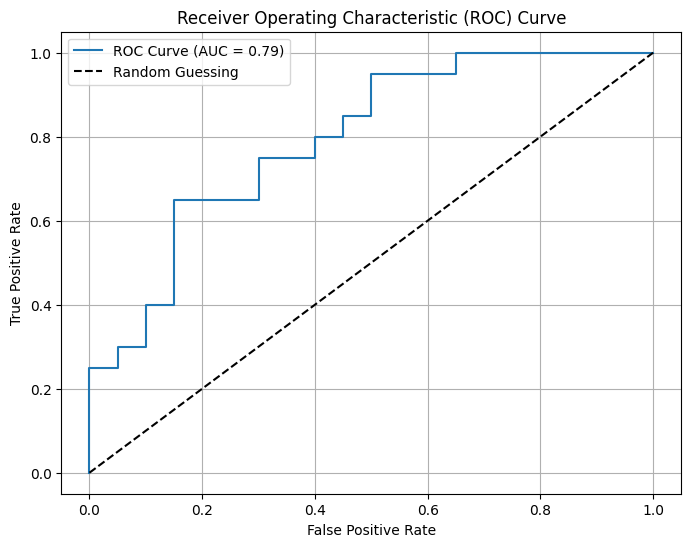

In [147]:
# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cnf, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Survived', 'Survived'], yticklabels=['Not Survived', 'Survived'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid(True)
plt.show()

**Reasoning**:
Display the confusion matrix and ROC curve plots as requested in the instructions.



In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Select features and target variable
X = df[['age', 'gender', 'speed', 'helmet', 'seatbelt']]
y = df['survived'] # 0 = fatal, 1 = No fatal

# Identify categorical and numerical features
categorical_features = ['gender', 'helmet', 'seatbelt']
numerical_features = ['age', 'speed']

# Create a column transformer for one-hot encoding
preprocessor = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough' # Keep numerical features
)

# Apply the transformer to the features
X_encoded = preprocessor.fit_transform(X)

# Display the shape of the encoded features
print("Shape of encoded features:", X_encoded.shape)

**Reasoning**:
Split the feature and target data into training and testing sets as instructed.

In [135]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (160, 8)
X_test shape: (40, 8)
y_train shape: (160,)
y_test shape: (40,)


In [136]:
from sklearn.linear_model import LogisticRegression

# Instantiate a LogisticRegression model
model = LogisticRegression()

# Fit the model to the training data
model.fit(X_train, y_train)

LogisticRegression()

**Reasoning**:
Make predictions on the test set, generate the confusion matrix, calculate predicted probabilities, compute ROC curve metrics (FPR, TPR, thresholds), and calculate the AUC.

In [137]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score

# Predict on the test set
y_pred = model.predict(X_test)

# Generate confusion matrix
cnf = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cnf)

# Calculate predicted probabilities for the positive class
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Compute ROC curve metrics
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Calculate AUC
auc = roc_auc_score(y_test, y_pred_proba)
print(f"Area Under the ROC Curve (AUC): {auc:.2f}")

Confusion Matrix:
 [[17  3]
 [10 10]]
Area Under the ROC Curve (AUC): 0.79


**Reasoning**:
Plot the confusion matrix as a heatmap and the ROC curve with the AUC score to visualize the model's performance.

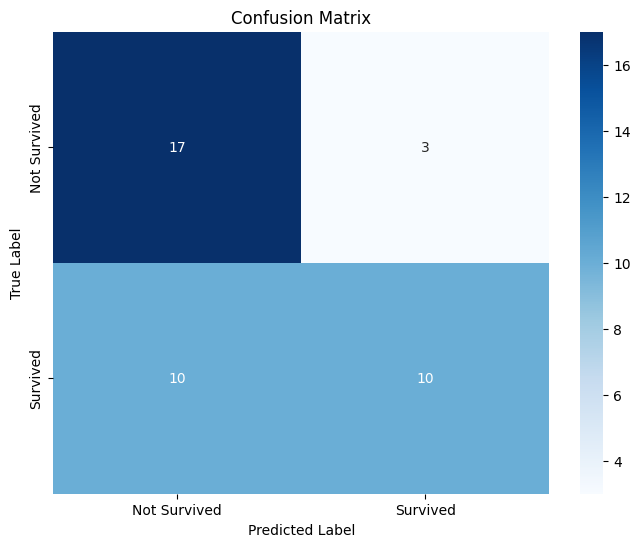

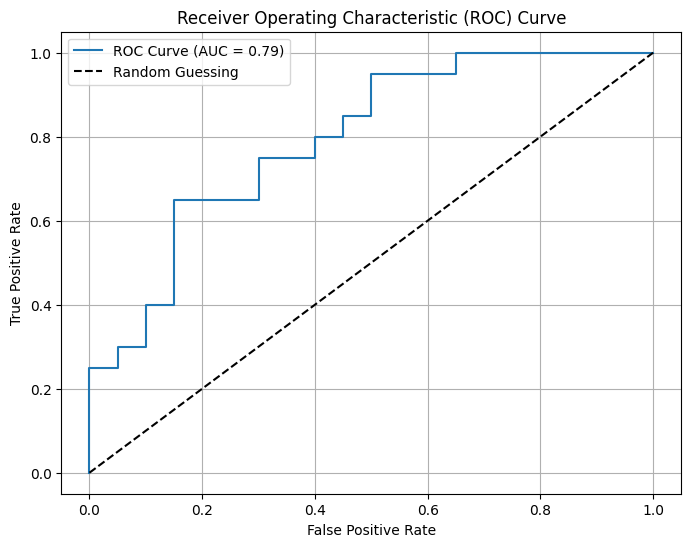

In [138]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cnf, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Survived', 'Survived'], yticklabels=['Not Survived', 'Survived'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid(True)
plt.show()

In [139]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
import pandas as pd

# Create a DataFrame with encoded features and target variable
X_encoded_df = pd.DataFrame(X_encoded, columns=preprocessor.get_feature_names_out(X.columns))
X_encoded_df['survived'] = y.reset_index(drop=True)


# Fit the statsmodels logistic regression model
model_sm = smf.logit('survived ~ ' + ' + '.join(X_encoded_df.columns.difference(['survived'])), data=X_encoded_df).fit()

# Print the model summary
print(model_sm.summary())

         Current function value: 0.535814
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:               survived   No. Observations:                  200
Model:                          Logit   Df Residuals:                      194
Method:                           MLE   Df Model:                            5
Date:                Sat, 06 Sep 2025   Pseudo R-squ.:                  0.2202
Time:                        03:35:29   Log-Likelihood:                -107.16
converged:                      False   LL-Null:                       -137.42
Covariance Type:            nonrobust   LLR p-value:                 9.543e-12
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 1.4636        nan        nan        nan         nan         nan
onehot__gender_Female     0.5247

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [146]:
# Print coefficients and intercept of the sklearn model
print("Coeficientes del modelo:", modelo.coef_)
print("Intercepto del modelo:", modelo.intercept_)

Coeficientes del modelo: [[0.64373227 0.13633223]]
Intercepto del modelo: [-3.57872953]


In [154]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
import pandas as pd

# Example prediction for a new instance
# Replace with the values you want to predict for
new_instance = pd.DataFrame([[23, 'Female', 50, 'Yes', 'No']],
                            columns=['age', 'gender', 'speed', 'helmet', 'seatbelt'])

# Select features and target variable from the accident.csv data
X = df[['age', 'gender', 'speed', 'helmet', 'seatbelt']]
y = df['survived'] # 0 = fatal, 1 = No fatal

# Identify categorical and numerical features
categorical_features = ['gender', 'helmet', 'seatbelt']
numerical_features = ['age', 'speed']

# Create and fit a column transformer for one-hot encoding on the entire dataset
preprocessor = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough' # Keep numerical features
)

X_encoded = preprocessor.fit_transform(X)

# Instantiate and fit the LogisticRegression model on the encoded accident.csv data
model_accident_sklearn = LogisticRegression()
model_accident_sklearn.fit(X_encoded, y)

# Encode the new instance using the fitted preprocessor
new_instance_encoded = preprocessor.transform(new_instance)

# Predict the probability of survival using the model trained on accident.csv
predicted_prob = model_accident_sklearn.predict_proba(new_instance_encoded)[:, 1]

print(f"Predicted probability of survival: {predicted_prob[0]:.4f}")

Predicted probability of survival: 0.7420
